In [2]:
EXP_NAME = "finetuning_2"

In [3]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
  from google.colab import userdata
  from google.colab import drive
  drive.mount('/content/drive')
  PROJECT_ROOT = userdata.get('PROJECT_ROOT')
else:
  PROJECT_ROOT = '../..'

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
sns.set_context('paper', font_scale=1.2)

search_results = pd.read_csv(f'{PROJECT_ROOT}/results/{EXP_NAME}/search_results.csv')

# Analysis

In [5]:
search_results['delta_desc_auc'] = abs(search_results['u_desc_sens_auc_mean'] - 0.5) - abs(search_results['x_desc_sens_auc_mean'] - 0.5)
search_results['fair_to_pred_ratio'] = search_results['fair_b'] / search_results['pred_a']
search_results['tc_to_pred_ratio'] = search_results['tc_b'] / search_results['pred_a']

# for i in range(5, len(search_results.columns)+1, 5):
#   print(search_results.iloc[:, i-5:i].describe())


In [6]:
params = ["corr_a", "desc_a", "pred_a", "fair_b", "fair_to_pred_ratio", "tc_b", "tc_to_pred_ratio", "u_ind_b"]
metrics = ["roc_auc", "auprc", "fnr", "fpr", "brier_score", "u_u_cca", "delta_desc_auc", "u_desc_recon_loss", "te_error", "internal_te_error"]

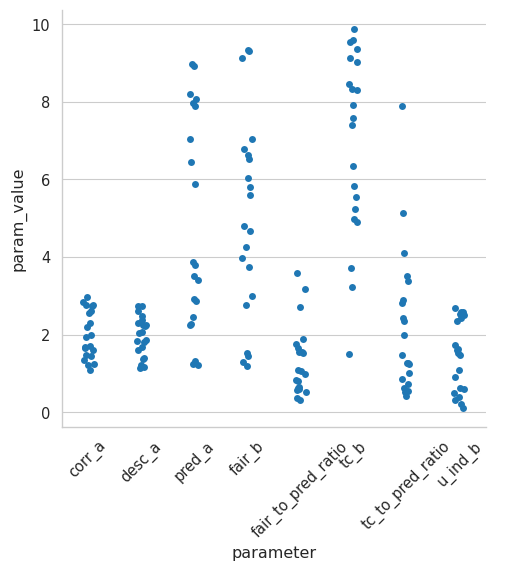

In [7]:
long_results = search_results[params + metrics].melt(id_vars=metrics, value_vars=params, value_name="param_value", var_name="parameter")

neg_delta_desc_auc = long_results['delta_desc_auc'] < -0.02

g = sns.catplot(long_results[neg_delta_desc_auc], x="parameter", y="param_value", kind="strip")
g.tick_params(axis='x', rotation=45)
plt.show()

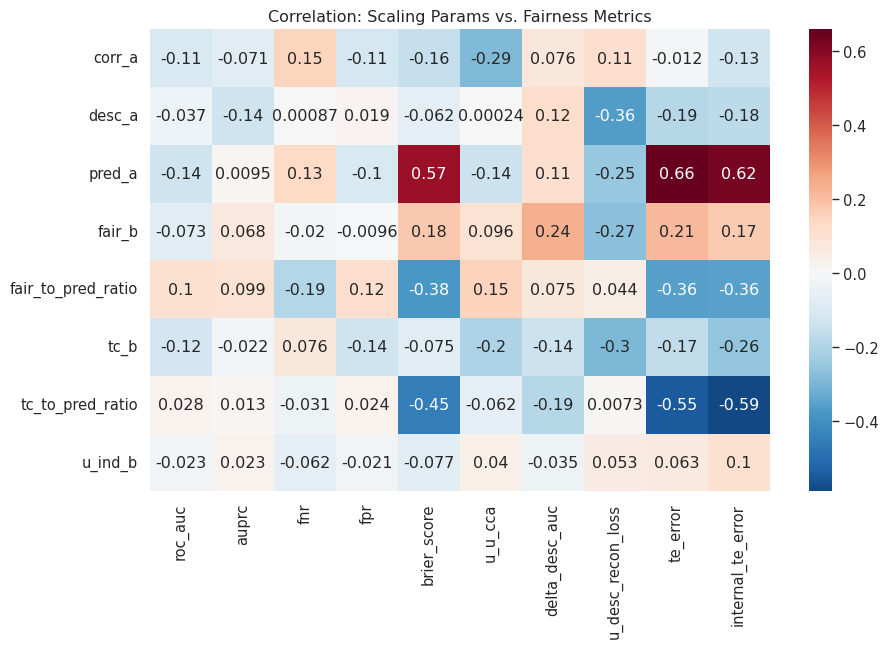

In [8]:
corr_matrix = search_results[params + metrics].corr(method='spearman')
param_metrics_corr = corr_matrix.loc[params, metrics]

plt.figure(figsize=(10, 6))
sns.heatmap(param_metrics_corr, annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation: Scaling Params vs. Fairness Metrics')
plt.show()

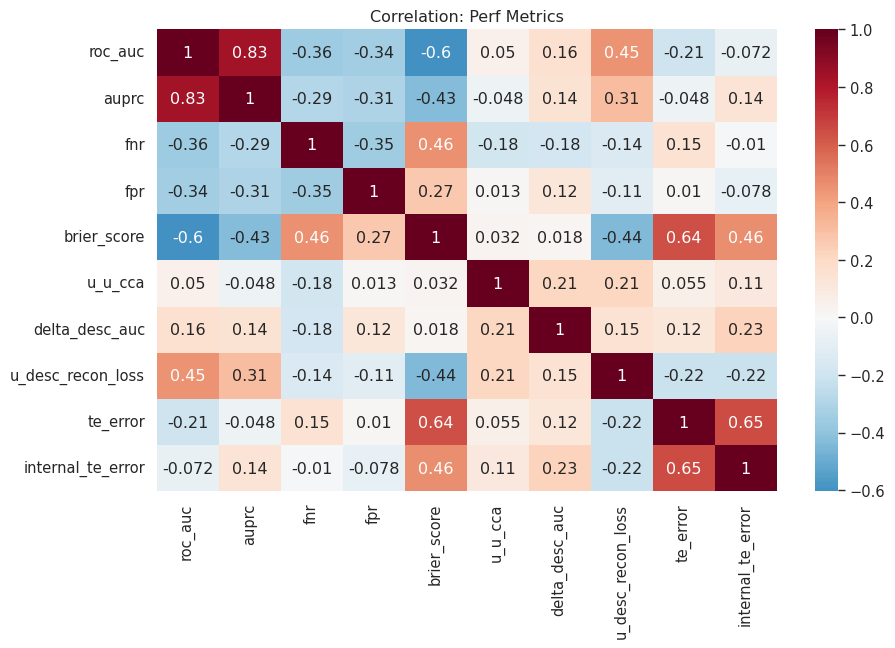

In [9]:
metrics_metrics_corr = corr_matrix.loc[metrics, metrics]

plt.figure(figsize=(10, 6))
sns.heatmap(metrics_metrics_corr, annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation: Perf Metrics')
plt.show()

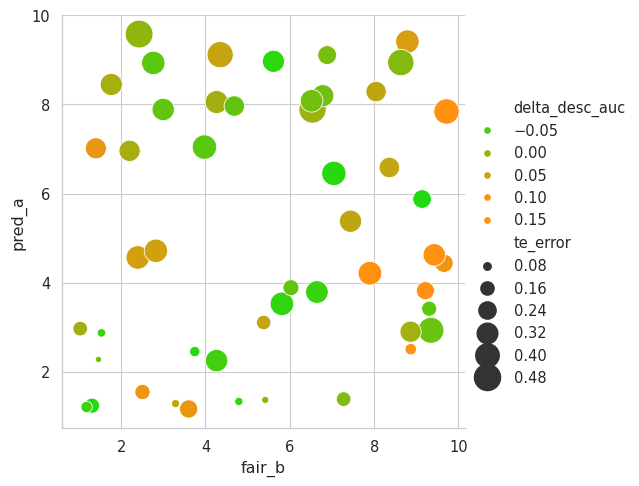

In [10]:
palette = sns.color_palette("blend:#20DB0F,#FF9010", as_cmap=True)
sns.relplot(data=search_results, x="fair_b", y="pred_a", hue="delta_desc_auc", size="te_error", kind="scatter", sizes=(20, 400), palette=palette, hue_norm=(-.08,.08))
plt.show()

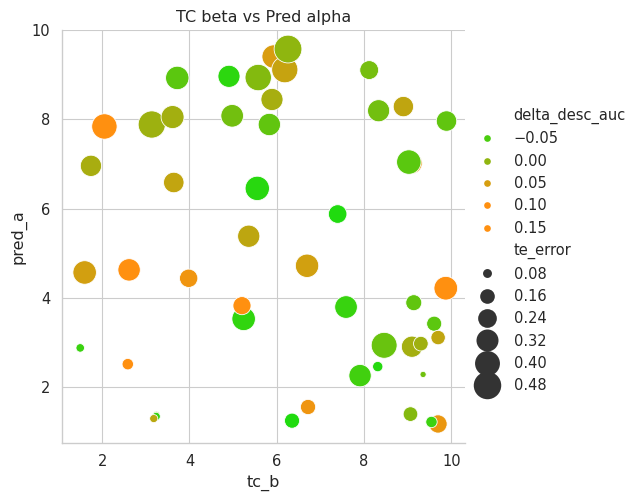

In [11]:
palette = sns.color_palette("blend:#20DB0F,#FF9010", as_cmap=True)
sns.relplot(data=search_results, x="tc_b", y="pred_a", hue="delta_desc_auc", size="te_error", kind="scatter", sizes=(20, 400), palette=palette, hue_norm=(-.08,.08))
plt.title("TC beta vs Pred alpha")
plt.show()

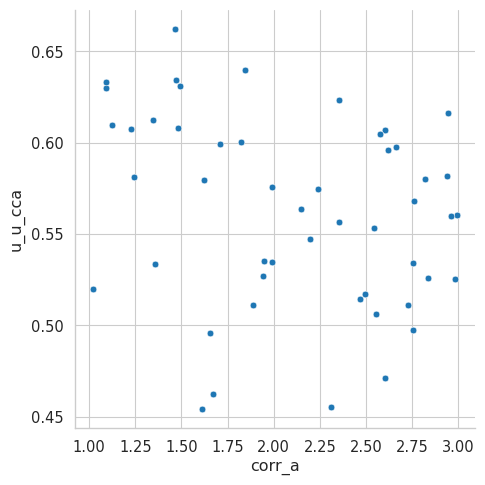

In [12]:
sns.relplot(data=search_results, x="corr_a", y="u_u_cca", kind="scatter")
plt.show()

pred_a ~ fair_b 
delta_desc_auc_bin
0    1.0
Name: proportion, dtype: float64

pred_a > fair_b 
delta_desc_auc_bin
0    0.458333
1    0.416667
2    0.125000
Name: proportion, dtype: float64

pred_a < fair_b 
delta_desc_auc_bin
0    0.500000
2    0.307692
1    0.192308
Name: proportion, dtype: float64

pred_a ~ tc_b 
delta_desc_auc_bin
0    1.0
Name: proportion, dtype: float64

pred_a > tc_b 
delta_desc_auc_bin
0    0.55
1    0.30
2    0.15
Name: proportion, dtype: float64

pred_a < tc_b 
delta_desc_auc_bin
0    0.413793
1    0.310345
2    0.275862
Name: proportion, dtype: float64


<Axes: >

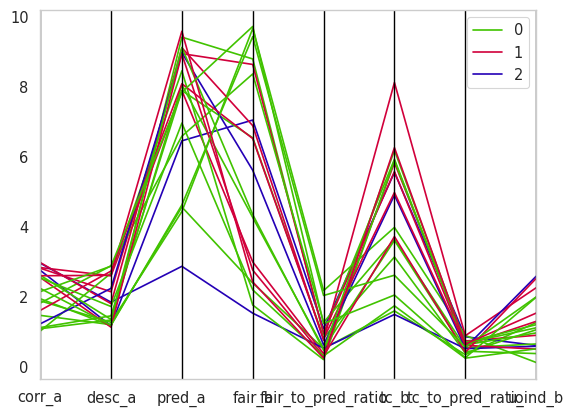

In [15]:

search_results['delta_desc_auc_bin'] = 0
search_results.loc[search_results['delta_desc_auc'] < 0, 'delta_desc_auc_bin'] = 1
search_results.loc[search_results['delta_desc_auc'] < -0.05, 'delta_desc_auc_bin'] = 2

pred_equal_fair = (1.01*search_results['pred_a'] > search_results['fair_b']) & (0.99*search_results['pred_a'] <= search_results['fair_b'])
pred_over_fair = 0.99*search_results['pred_a'] > search_results['fair_b']
fair_over_pred = 1.01*search_results['pred_a'] <= search_results['fair_b']
pred_equal_fair = (1.01*search_results['pred_a'] > search_results['tc_b']) & (0.99*search_results['pred_a'] <= search_results['tc_b'])
pred_over_tc = 0.99*search_results['pred_a'] > search_results['tc_b']
tc_over_pred = 1.01*search_results['pred_a'] <= search_results['tc_b']

print("pred_a ~ fair_b ")
print(search_results.loc[pred_equal_fair, 'delta_desc_auc_bin'].value_counts(normalize=True))
print("\npred_a > fair_b ")
print(search_results.loc[pred_over_fair, 'delta_desc_auc_bin'].value_counts(normalize=True))
print("\npred_a < fair_b ")
print(search_results.loc[fair_over_pred, 'delta_desc_auc_bin'].value_counts(normalize=True))
print("\npred_a ~ tc_b ")
print(search_results.loc[pred_equal_fair, 'delta_desc_auc_bin'].value_counts(normalize=True))
print("\npred_a > tc_b ")
print(search_results.loc[pred_over_tc, 'delta_desc_auc_bin'].value_counts(normalize=True))
print("\npred_a < tc_b ")
print(search_results.loc[tc_over_pred, 'delta_desc_auc_bin'].value_counts(normalize=True))



pd.plotting.parallel_coordinates(search_results.loc[pred_over_tc, params + ["delta_desc_auc_bin"]], "delta_desc_auc_bin", 
                                 color=["#41c300","#d1003b","#2400b6"])